In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/processed/cleaned_insurance.csv', index_col=0)
df.head()

,age,sex,bmi,children,smoker,charges
0,19,0,27.900,0,1,16884.92400
1,18,1,33.770,1,0,1725.55230
2,28,1,33.000,3,0,4449.46200
3,33,1,22.705,0,0,21984.47061
4,32,1,28.880,0,0,3866.85520


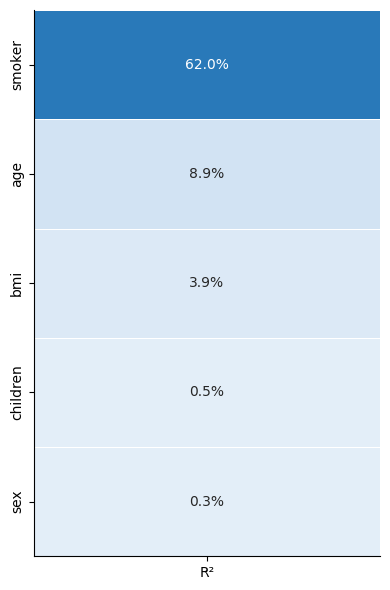

In [9]:
# Graphing the R squared
plt.figure(figsize=(4, 6))

charges_corr = df.corr(numeric_only=True)["charges"].drop('charges').sort_values(ascending=False)
df_corr = charges_corr.to_frame(name='correlation')
df_corr['R²'] = df_corr['correlation'] ** 2
df_corr = df_corr.drop(columns='correlation')


sns.heatmap(
    df_corr,
    annot=True,
    fmt=".1%",
    cmap="Blues",
    vmin=-0.1, vmax=0.9,
    linewidths=0.5,
    cbar=False
)

sns.despine()
plt.tight_layout()
plt.show()


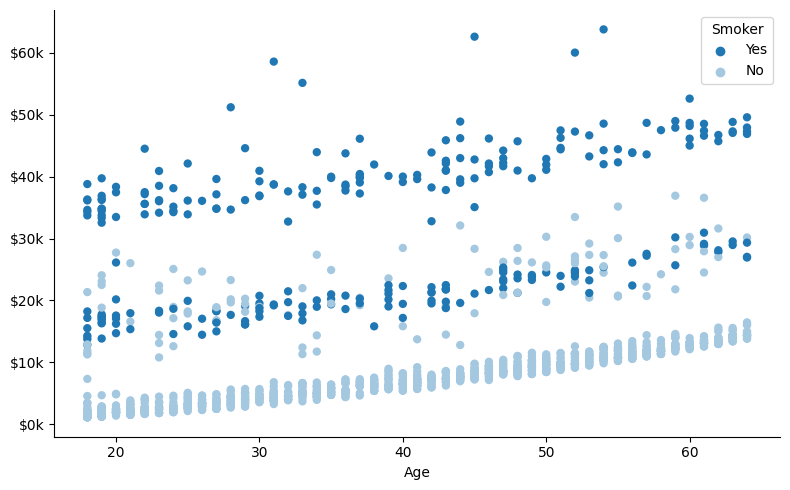

In [6]:
# Charges vs Age vs Smoker
plt.figure(figsize=(8, 5))

sns.scatterplot(x='age', y='charges', data=df, hue='smoker', hue_order=[1, 0], palette=['#1F77B4', '#A5C8E1'], edgecolor='none')

handles, labels = plt.gca().get_legend_handles_labels()
new_labels = ['No' if label == '0' else 'Yes' for label in labels]
plt.legend(handles, new_labels, title='Smoker', loc='upper right')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}k'))

plt.title('')
plt.xlabel('Age')
plt.ylabel('')

sns.despine()
plt.tight_layout()
plt.show()

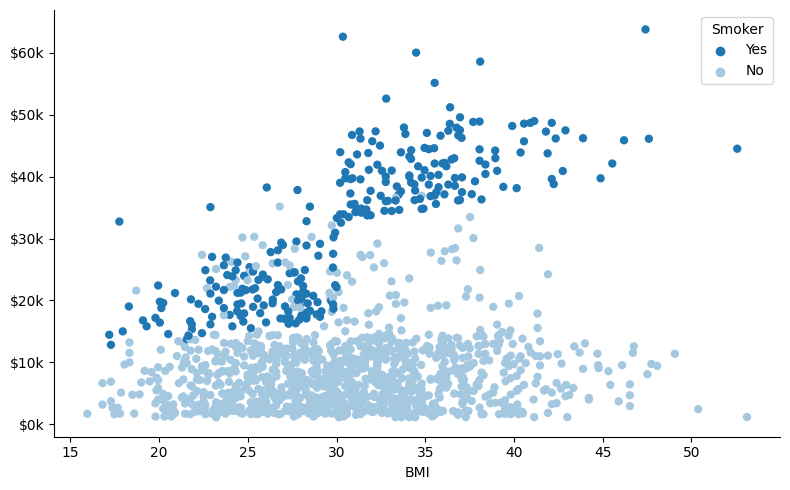

In [7]:
# Charges vs BMI vs Smoker
plt.figure(figsize=(8, 5))

sns.scatterplot(x='bmi', y='charges', data=df, hue='smoker', hue_order=[1, 0], palette=['#1F77B4', '#A5C8E1'], edgecolor='none')

handles, labels = plt.gca().get_legend_handles_labels()
new_labels = ['No' if label == '0' else 'Yes' for label in labels]
plt.legend(handles, new_labels, title='Smoker', loc='upper right')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}k'))

plt.xlabel('BMI')
plt.ylabel('')

sns.despine()
plt.tight_layout()
plt.show()